In [2]:
# analysis
import numpy as np
import pandas as pd 

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# single-cell
import scanpy as sc
import liana as li

from pathlib import Path
import os 

# seting global dir
cwd=Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent) 
os.getcwd()

'/Users/max/Documents/repositories/MSB_project'

### Bazy danych i referncje

In [3]:
adata = sc.datasets.pbmc68k_reduced()
adata

AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

wizualizacja UMAP, pytania:
- w jaki sposób je rozdziela
- na czym tutaj polegają trajektorie
- względem czego to determinuje

no bo rozumiem, że celem jest rozróżnienie grup komórek, ale zastanawiam się czym się różnią poszczególne metody i w jaki sposób można je wykorzystać. 

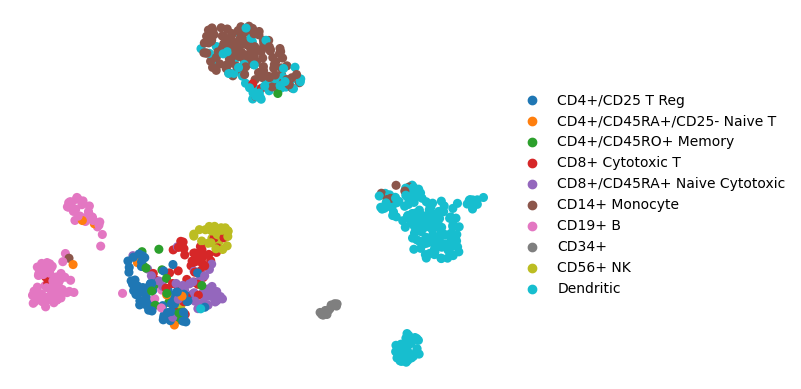

In [4]:
sc.pl.umap(adata, color='bulk_labels', title='', frameon=False)

In [5]:
# tutaj możemy otrzymać informacje o danych
adata.raw.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 174400 stored elements and shape (700, 765)>

In [6]:
# dostępne methody z referencjami 
li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


In [7]:
# dostępne bazy danych z informacjami o ligand receptorach 
li.resource.show_resources()


['baccin2019',
 'cellcall',
 'cellchatdb',
 'cellinker',
 'cellphonedb',
 'celltalkdb',
 'connectomedb2020',
 'consensus',
 'embrace',
 'guide2pharma',
 'hpmr',
 'icellnet',
 'italk',
 'kirouac2010',
 'lrdb',
 'mouseconsensus',
 'ramilowski2015']

### Informacje z biblioteki

#### Notatki

Fragment o tym w jaki sposób dostajemy informacje z danej biblioteki



**Wyniki z komendy**

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


#### Pytania

Przy ustawianiu [Prior knowledge](https://liana-py.readthedocs.io/en/latest/notebooks/prior_knowledge.html) jak i czy trzeba (bo rozumiem że w zależności od gatunku dostaniemy inne receptory i ligandy dla danych genów, bo to raczej powinno być bardziej uniwersalne) 

In [8]:
from liana.mt import rank_aggregate
# informacja o metodzie agregacji 
# rank_aggregate.describe()
?rank_aggregate.__call__


Signature:
rank_aggregate.__call__(
    adata: 'an.AnnData | MuData',
    groupby: 'str',
    resource_name: 'str' = 'consensus',
    expr_prop: 'float' = 0.1,
    min_cells: 'int' = 5,
    groupby_pairs: 'DataFrame | None' = None,
    base: 'float' = np.float64(2.718281828459045),
    aggregate_method: 'str' = 'rra',
    consensus_opts: 'list | None' = None,
    return_all_lrs: 'bool' = False,
    key_added: 'str' = 'liana_res',
    use_raw: 'bool | None' = True,
    layer: 'str | None' = None,
    de_method: 'str' = 't-test',
    n_perms: 'int' = 1000,
    seed: 'int' = 1337,
    n_jobs: 'int' = 1,
    resource: 'DataFrame | None' = None,
    interactions: 'list | None' = None,
    mdata_kwargs: 'dict | None' = None,
    spatial_key: 'str | None' = None,
    spatial_kwargs: 'dict | None' = None,
    inplace: 'bool' = True,
    verbose: 'bool | None' = False,
)
Docstring:
Get an aggregate of ligand-receptor scores from multiple methods.

Parameters
----------
adata
    Annotated data 

In [9]:
# 
rank_aggregate.describe()

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


### Analiza stanu stacjonarnego (steady state)

#### Pojedyncze metody

##### jakich macierzy i wiedzy prior (resources) używają metody liany

##### Macierze
- UWAGA: domyślnie liana używa `raw` data, żeby wybrac inną transformacje trzeba zdeterminować odpowiednią warstwę

##### Prior

Wiedza prior z baz danych, polega na odpowiednim mapowaniu genów (*symobli genetycznych* - w jednym gatunku są unikalne, między gatunkami niekoniecznie - problem z homologią )  

- UWAGA: domyśnie liana używa `resource_name='consensus'` czyli zbiera wszystkie dane i używa symboli genetycznych człowieka

#### Użyte statystyki - co robią? - opis danych 

##### Źródło (source) i cele (target) 
Identyfikujemy poprzez te zmienne komórki które wysyłają / odbierają komunikacje

##### ligand receptor complex_* ligandy, receptory ich kompleksy  
W komunikacji nie używamy oczywiście ligandów i receptorów, ponieważ CCC (cell-cell communication) jest bardziej złożona. Dodatkowo my wyłapujemy **tylko komplesy białkowe**, zatem my sprawdzamy ekspresje tylko po pod jednostakch ligandów / receptorów i mamy osobno nazwane jakiego kompleksu to jest fragment (bierzemy po minimum tego kompleksu) 

Pytanie:
- czym jest ptor entities, more specifically: ligand and receptor are the two entities that potentially interact. As a reminder, CCC events are not limited to secreted signalling, but we refer to them as ligand and receptor for simplicity.

##### *_props (proporcja) 
Tutaj mówimy w jakiej proporcji komórek występuje dany ligand / receptor. W przypadku małych zliczeń interpretujemy je jako false positive (tutaj interpretujey to tak, że w sposób losowy się tam znalazły) 

##### *_mean
**_means**

ile średnio danej danej ekspresji przypada na komórkę (ale to jaka jest skala to jest per milion genes wtedy czy po prosu ile zliczeń średnio)

**lr_means**

ile średnio jest ekspresji **na pary** ligand receptor - miara interakcji 

Proporcja komórek które mają

##### cellphone_pvals
Wyniki $p$ value po tych permutacyjnych testach jako miara **specyficzności** (wiele metryk musi pokazać zgodny wynik) 

##### Inne 
Metryki z różnych metryk, rozdzielamy je względem **siły(magnitutde)** działania danej pary ligand-receptor, oraz **specyficzność (specifity)** które możemy otrzymać

##### Pytania
- jak mamy *_means to w jaki sposób mamy rozumieć otrzymaną wartość?? Czy to świadczy o 


In [10]:
# import wszystkich metod
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [11]:
# run cellphonedb
# UWAGA: domyślnie te metody są zapisywane w 'liana_res'
cellphonedb(adata,
            groupby='bulk_labels', 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='consensus',
            expr_prop=0.1, # co robi to ?? 
            verbose=True, 
            key_added='cpdb_res' # w jaki sposób zapisujemy nasze wyniki / domyślnie liana_res
            )

Using resource `consensus`.
Using `.raw`!
/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/Users/max/.micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.94 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 700 samples and 43 features


100%|██████████| 1000/1000 [00:01<00:00, 653.39it/s]


In [12]:
adata.uns # to jest ogólnie słownik z unstructured annotation

{'bulk_labels_colors': array(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b',
        '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'], dtype=object),
 'louvain': {'params': {'random_state': array([0]), 'resolution': array([1])}},
 'louvain_colors': array(['#023fa5', '#7d87b9', '#bec1d4', '#d6bcc0', '#bb7784', '#8e063b',
        '#4a6fe3', '#8595e1', '#b5bbe3', '#e6afb9', '#e07b91'],
       dtype=object),
 'neighbors': {'params': {'method': 'umap', 'n_neighbors': array([10])}},
 'pca': {'variance': array([30.928047 , 21.182432 , 14.686322 , 11.570731 ,  9.232856 ,
          7.3497834,  4.338316 ,  3.197439 ,  3.1584399,  2.910167 ,
          2.649945 ,  2.540031 ,  2.4057367,  2.3872852,  2.2644212,
          2.2250588,  2.189688 ,  2.134691 ,  2.0775423,  2.0560663,
          2.007874 ,  1.9969993,  1.9606696,  1.9441428,  1.9129871,
          1.9063067,  1.8529838,  1.8260264,  1.7946786,  1.7489465,
          1.7449841,  1.7298484,  1.70099  ,  1.6571085,  1.6406441,
  

In [18]:
adata.uns['cpdb_res']


,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
482,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.612842,0.421053,Dendritic,CD4+/CD45RO+ Memory,2.575263,0.000
321,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.596125,0.500000,Dendritic,CD4+/CD45RA+/CD25- Naive T,2.566905,0.000
989,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.483977,0.302326,Dendritic,CD14+ Monocyte,2.510830,0.000
651,HLA-DRA,HLA-DRA,4.537684,0.995833,LAG3,LAG3,0.399500,0.240741,Dendritic,CD8+ Cytotoxic T,2.468592,0.000
1392,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.373671,0.270833,Dendritic,Dendritic,2.455678,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...
1148,GNAI2,GNAI2,0.183538,0.153846,S1PR5,S1PR5,0.171846,0.153846,CD34+,CD34+,0.177692,0.914
1370,TNFSF13B,TNFSF13B,0.212000,0.153846,CD40,CD40,0.142317,0.100000,CD34+,Dendritic,0.177158,0.507
272,LCK,LCK,0.192800,0.126316,CD8A,CD8A_CD8B,0.161000,0.125000,CD19+ B,CD4+/CD45RA+/CD25- Naive T,0.176900,0.998
327,LCK,LCK,0.169550,0.116667,CD8A,CD8A_CD8B,0.161000,0.125000,Dendritic,CD4+/CD45RA+/CD25- Naive T,0.165275,1.000


#### Wykresy

##### dotplot
- mamy iformacje o o tym ile było istotnych odczytów
- jaka była średnia ekspresja liganda i receptora

- wybrakowane 
-  byłī to fasle positive'y zostały wybrakowane 
  
##### Tileplot




##### Dane nieagregowane 

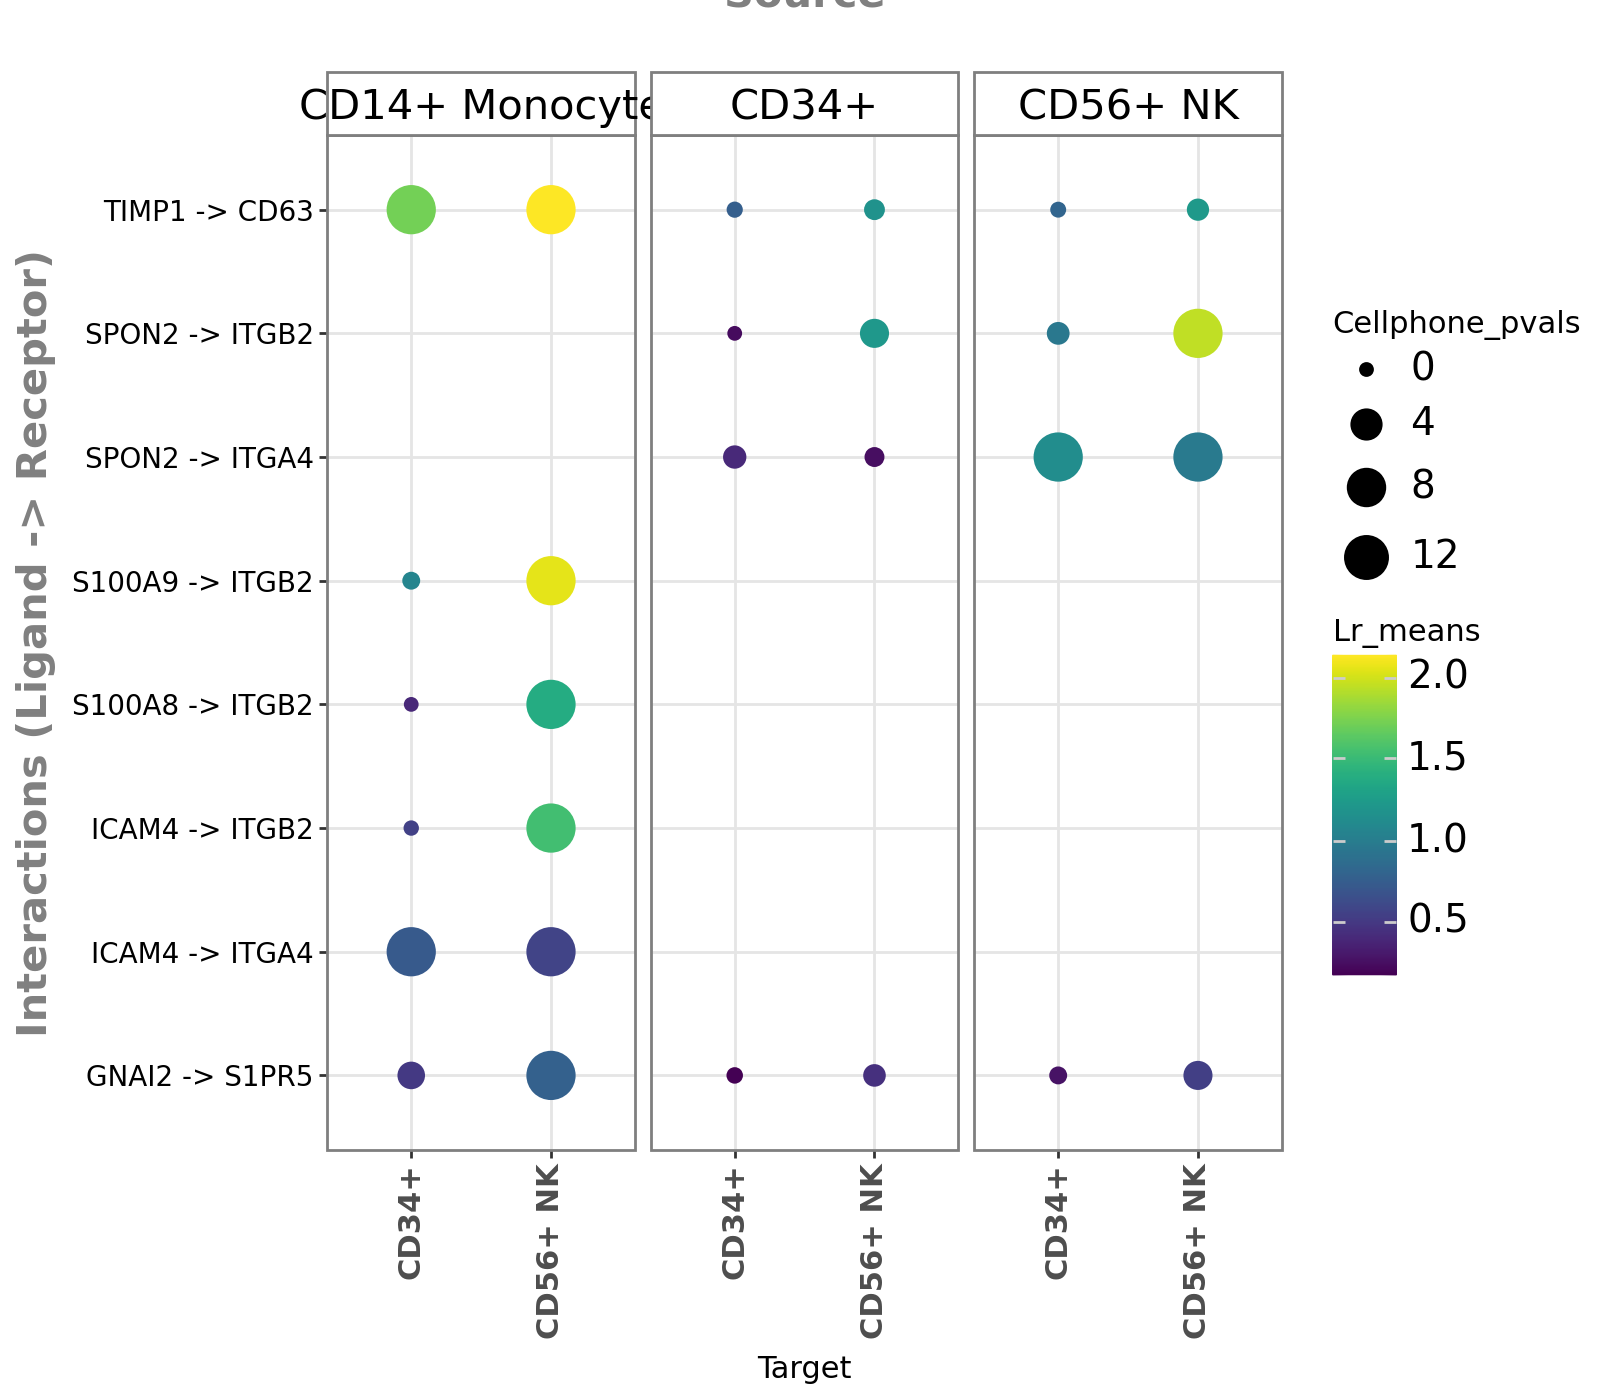

In [77]:
li.pl.dotplot(adata = adata, 
              colour='lr_means',
              size='cellphone_pvals',
              inverse_size=True, # we inverse sign since we want small p-values to have large sizes
              source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
              target_labels=['CD34+', 'CD56+ NK'],
              figure_size=(8, 7),
              # finally, since cpdbv2 suggests using a filter to FPs
              # we filter the pvals column to <= 0.05
              filter_fun=lambda x: x['cellphone_pvals'] <= 0.05,
              uns_key='cpdb_res' # uns_key to use, default is 'liana_res' 
             )

/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


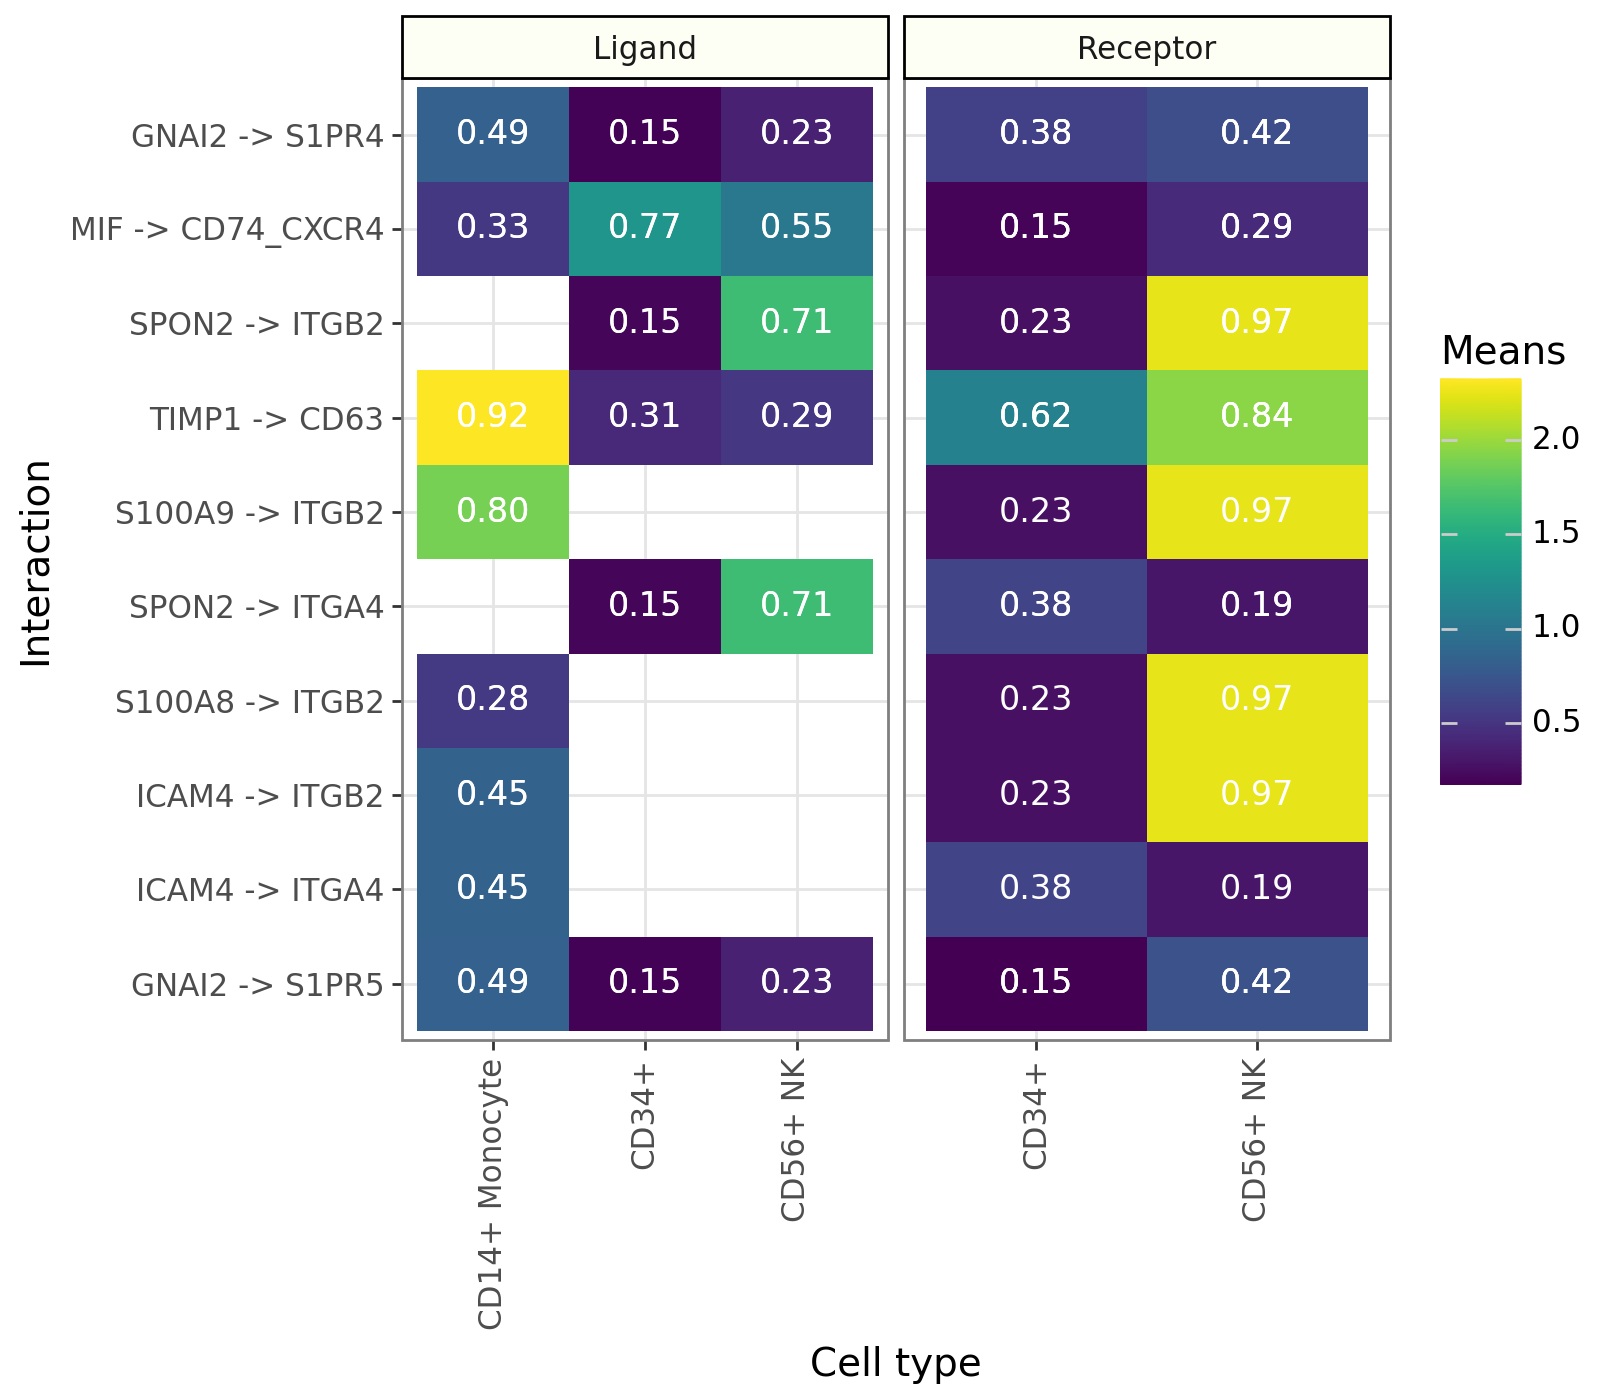

In [67]:

my_plot = li.pl.tileplot(adata = adata, 
                         # NOTE: fill & label need to exist for both
                         # ligand_ and receptor_ columns
                         fill='means',
                         label='props',
                         label_fun=lambda x: f'{x:.2f}',
                         top_n=10, 
                         orderby='cellphone_pvals', #.TODO - tutaj jest ważne, ponieważ mo
                         orderby_ascending=True,
                         source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
                         target_labels=['CD34+', 'CD56+ NK'],
                         uns_key='cpdb_res', # NOTE: default is 'liana_res'
                         source_title='Ligand',
                         target_title='Receptor',
                         figure_size=(8, 7)
                         )
my_plot

***

#### Grupowanie wielu metod AGREGACJA

##### Rozpoznanie metod. 

przy methodzie rank_aggregate.describe() dostajemy opis jakie inne metody zostały użyte 

In [68]:
# Run rank_aggregate
li.mt.rank_aggregate(adata, 
                     groupby='bulk_labels',
                     resource_name='consensus',
                     expr_prop=0.1,
                     verbose=True)

Using resource `consensus`.
Using `.raw`!
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.94 of entities in the resource are missing from the data.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/home/maxi7524/micromamba/envs/sc_e

Generating ligand-receptor stats for 700 samples and 43 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:02<00:00, 421.14it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [69]:
adata.uns['liana_res']

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
1209,Dendritic,CD4+/CD45RO+ Memory,HLA-DRA,CD4,2.575263,0.00,2.780884,0.723815,1.431303,0.065077,0.736772,0.001137,0.000653
1188,Dendritic,CD4+/CD45RA+/CD25- Naive T,HLA-DRA,CD4,2.566905,0.00,2.705027,0.709428,1.332656,0.063302,0.734081,0.001137,0.000911
1210,Dendritic,CD4+/CD45RO+ Memory,HLA-DRB1,CD4,2.415010,0.00,2.584465,0.712731,1.331341,0.060203,0.729607,0.001137,0.001211
1205,Dendritic,CD4+/CD45RO+ Memory,HLA-DPB1,CD4,2.367473,0.00,2.526199,0.731297,1.447014,0.068953,0.727352,0.001137,0.001377
1189,Dendritic,CD4+/CD45RA+/CD25- Naive T,HLA-DRB1,CD4,2.406652,0.00,2.513965,0.698344,1.232695,0.058561,0.726870,0.001137,0.001741
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,CD14+ Monocyte,CD19+ B,TNFSF13B,CD40,0.480661,0.00,0.230911,0.625032,0.749677,0.263468,0.446458,0.001137,1.000000
27,CD14+ Monocyte,CD19+ B,MIF,CD74_CXCR4,0.373386,1.00,0.117386,-0.365118,-0.700572,0.002079,0.365106,1.000000,1.000000
17,CD14+ Monocyte,CD14+ Monocyte,IL16,CD4,0.385713,0.11,0.139119,0.087500,0.144150,0.013833,0.385009,0.307125,1.000000
1280,Dendritic,Dendritic,IL16,CD4,0.370413,0.16,0.137195,0.049981,0.013582,0.013642,0.383361,0.314437,1.000000


In [70]:

rank_aggregate.describe()


Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


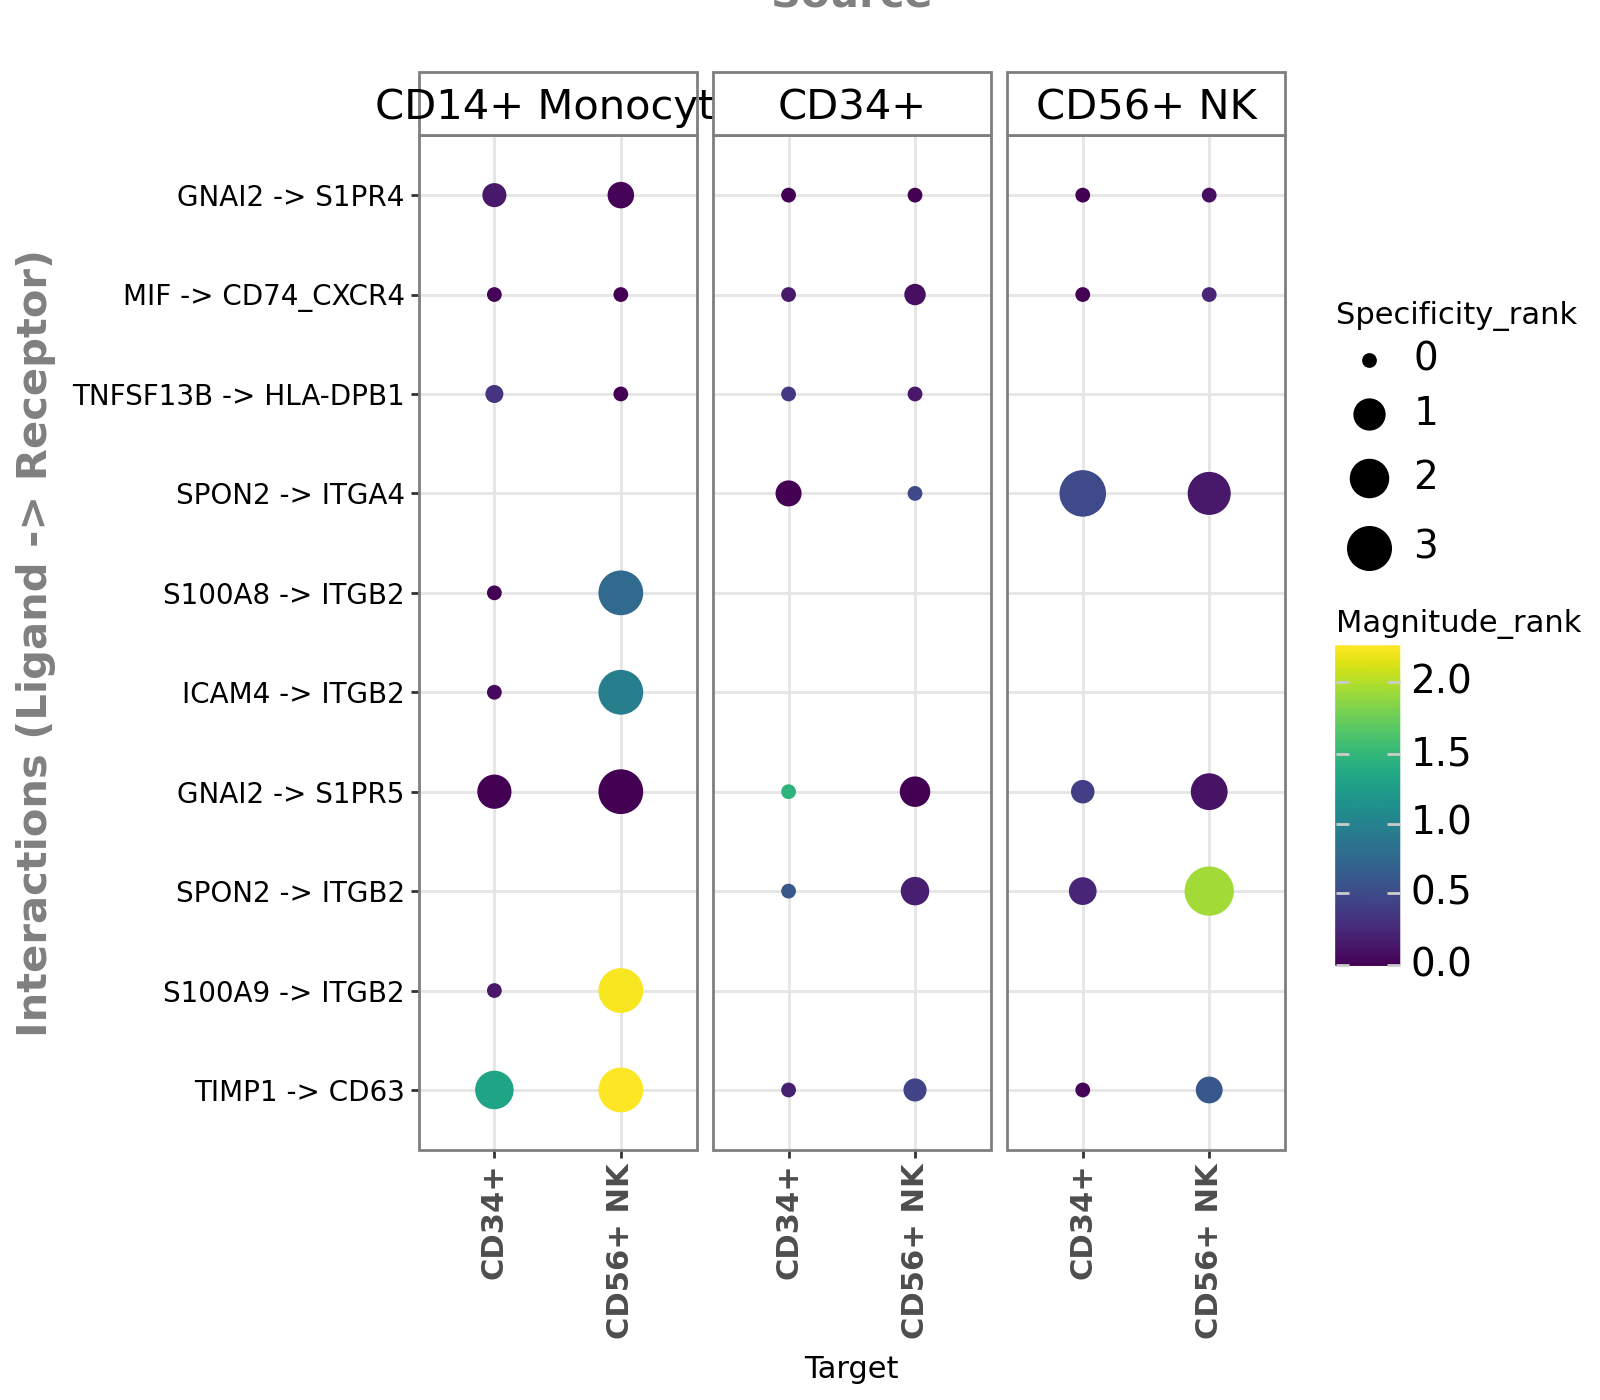

In [71]:
# tutaj używamy agregowanych danych 
li.pl.dotplot(adata = adata, 
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=True,
              source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
              target_labels=['CD34+', 'CD56+ NK'],
              top_n=10, 
              uns_key='liana_res',
              orderby='magnitude_rank',
              orderby_ascending=True,
              figure_size=(8, 7)
             )

In [ ]:

my_plot = li.pl.tileplot(adata = adata, 
                         # NOTE: fill & label need to exist for both
                         # ligand_ and receptor_ columns
                         fill='means',
                         label='props',
                         label_fun=lambda x: f'{x:.2f}',
                         top_n=10, 
                         orderby='cellphone_pvals', #.TODO - tutaj jest ważne, ponieważ mo
                         orderby_ascending=True,
                         source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
                         target_labels=['CD34+', 'CD56+ NK'],
                         uns_key='cpdb_res', # NOTE: default is 'liana_res'
                         source_title='Ligand',
                         target_title='Receptor',
                         figure_size=(8, 7)
                         )
my_plot

In [75]:
adata.uns['liana_res']

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
1209,Dendritic,CD4+/CD45RO+ Memory,HLA-DRA,CD4,2.575263,0.00,2.780884,0.723815,1.431303,0.065077,0.736772,0.001137,0.000653
1188,Dendritic,CD4+/CD45RA+/CD25- Naive T,HLA-DRA,CD4,2.566905,0.00,2.705027,0.709428,1.332656,0.063302,0.734081,0.001137,0.000911
1210,Dendritic,CD4+/CD45RO+ Memory,HLA-DRB1,CD4,2.415010,0.00,2.584465,0.712731,1.331341,0.060203,0.729607,0.001137,0.001211
1205,Dendritic,CD4+/CD45RO+ Memory,HLA-DPB1,CD4,2.367473,0.00,2.526199,0.731297,1.447014,0.068953,0.727352,0.001137,0.001377
1189,Dendritic,CD4+/CD45RA+/CD25- Naive T,HLA-DRB1,CD4,2.406652,0.00,2.513965,0.698344,1.232695,0.058561,0.726870,0.001137,0.001741
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,CD14+ Monocyte,CD19+ B,TNFSF13B,CD40,0.480661,0.00,0.230911,0.625032,0.749677,0.263468,0.446458,0.001137,1.000000
27,CD14+ Monocyte,CD19+ B,MIF,CD74_CXCR4,0.373386,1.00,0.117386,-0.365118,-0.700572,0.002079,0.365106,1.000000,1.000000
17,CD14+ Monocyte,CD14+ Monocyte,IL16,CD4,0.385713,0.11,0.139119,0.087500,0.144150,0.013833,0.385009,0.307125,1.000000
1280,Dendritic,Dendritic,IL16,CD4,0.370413,0.16,0.137195,0.049981,0.013582,0.013642,0.383361,0.314437,1.000000


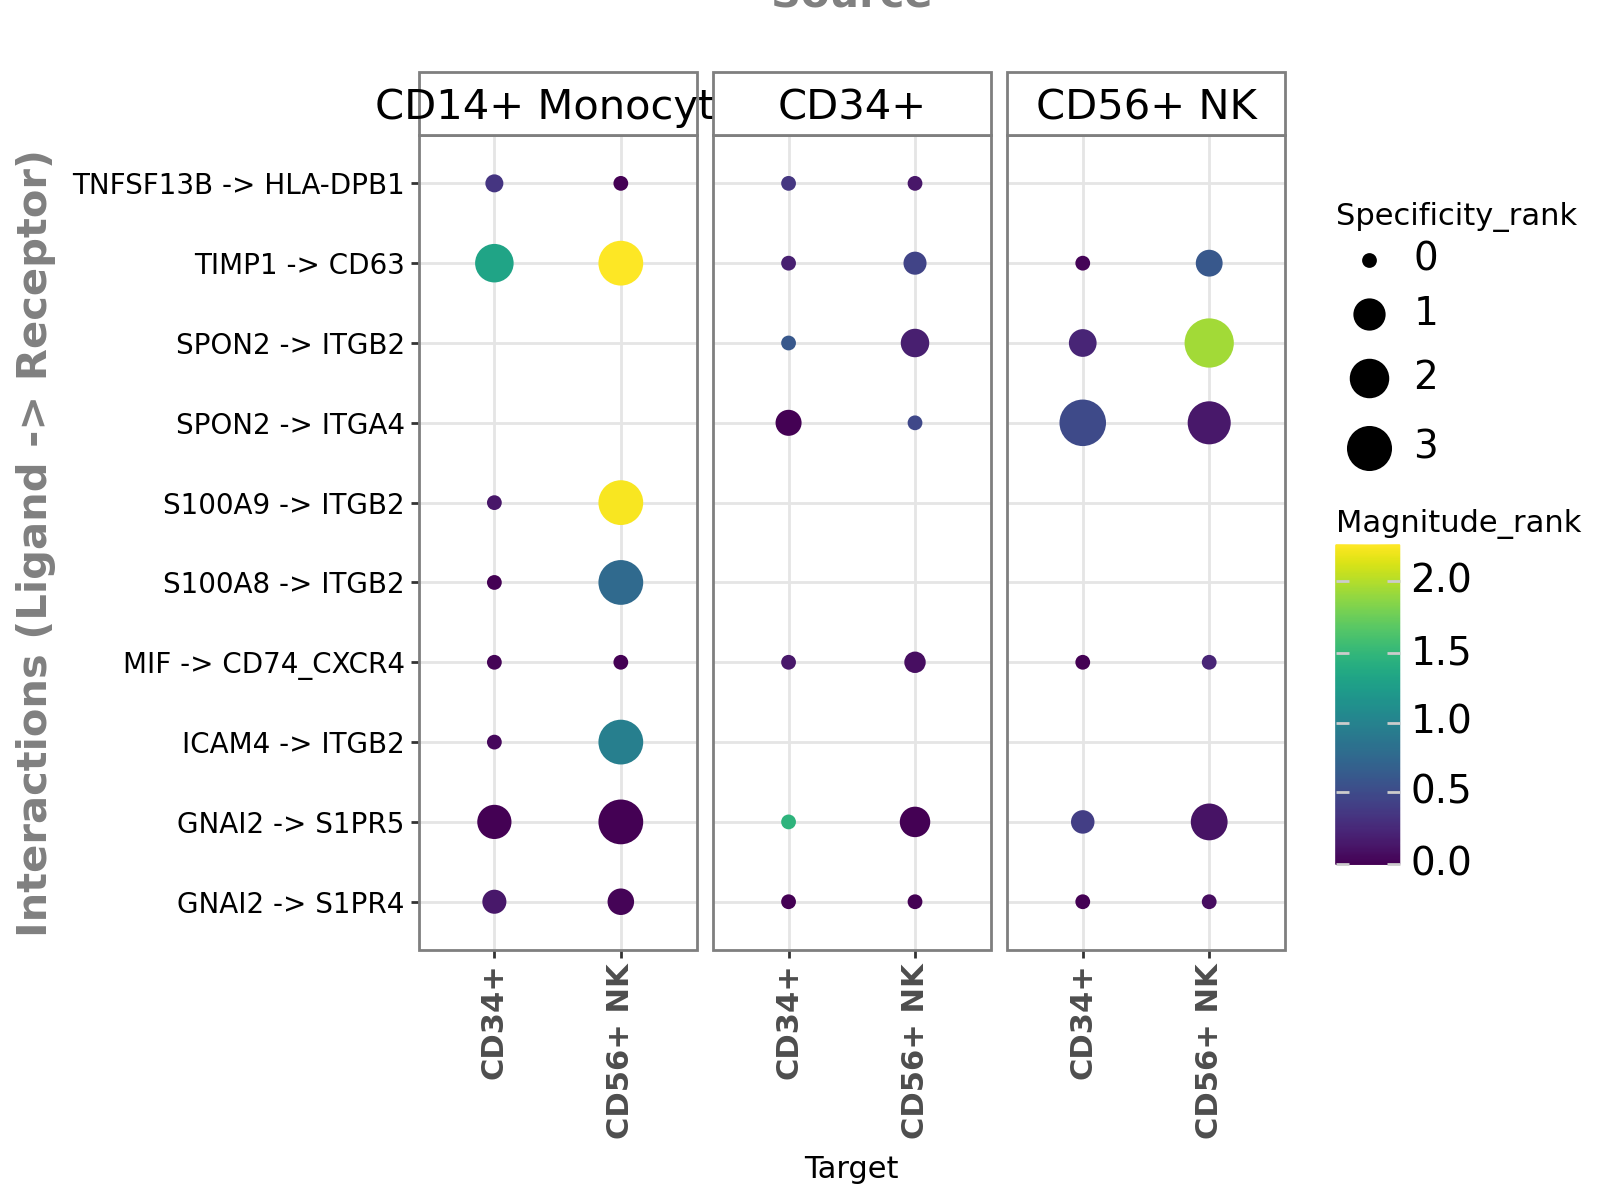

In [76]:
li.pl.dotplot(adata = adata, 
                        colour='magnitude_rank',
                        inverse_colour=True,
                        size='specificity_rank',
                        inverse_size=True,
                        source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
                        target_labels=['CD34+', 'CD56+ NK'],
                        # TODO - here we apply filter for obtaining only specify results 
                        filter_fun=lambda x: x['specificity_rank'] >= 0.7,
                       )

<Axes: >

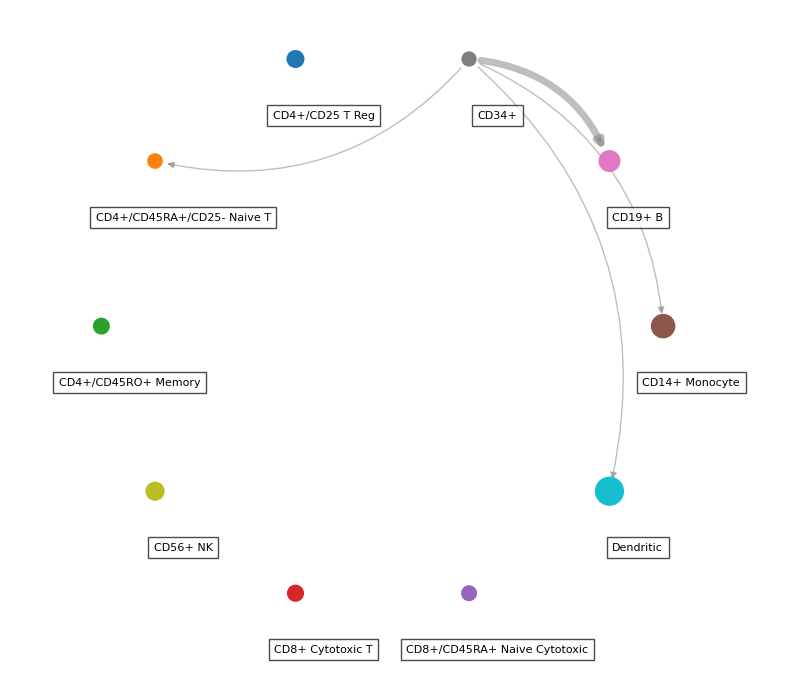

In [73]:
li.pl.circle_plot(adata,
                  groupby='bulk_labels',
                  score_key='magnitude_rank',
                  inverse_score=True,
                  source_labels='CD34+',
                  filter_fun=lambda x: x['specificity_rank'] <= 0.05,
                  pivot_mode='counts', # NOTE: this will simply count the interactions, 'mean' is also available
                  figure_size=(10, 10),
                  )

Using part of methods

In [ ]:
# methods = [logfc, geometric_mean]
# new_rank_aggregate = li.mt.AggregateClass(li.mt.aggregate_meta, methods=methods)

In [ ]:
# new_rank_aggregate(adata,
#                    groupby='bulk_labels',
#                    expr_prop=0.1, 
#                    verbose=True,
#                    # Note that with this option, we don't perform permutations
#                    # and hence we exclude the p-value for geometric_mean, as well as specificity_rank
#                    n_perms=None,
#                    use_raw=True,
#                    )

Using resource `consensus`.
Using `.raw`!
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.94 of entities in the resource are missing from the data.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:296: Futur

Generating ligand-receptor stats for 700 samples and 43 features
Assuming that counts were `natural` log-normalized!
Running log2FC
Running Geometric Mean
